# Analisis de Datos Exploratorio 
En este notebook vamos a dar un primer hallazgo para poder saber con que datos estamos trabajando, saber si hay datos nulos o no normalizados. Y mas que nada poder entender con que nos estamos enfrentando con este proyeto.

El objetivo de este proyecto es poder identificar fraudes bancarios, cuales son los mas comunies y lo mas importante como prevenirlos, se va a estar trabajando con el siguiente base de datos.

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
data = pd.read_csv('../data/01_raw/PS_20174392719_1491204439457_log.csv')

In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [23]:
data.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


Aquí tienes una tabla en formato Markdown con 3 columnas y 3 filas:

| Nombre Variable| Que significa? | Tipo de Variable |
| --- | --- | --- |
| Fila 1, Celda 1 | Fila 1, Celda 2 | Fila 1, Celda 3 |
| Fila 2, Celda 1 | Fila 2, Celda 2 | Fila 2, Celda 3 |
| Fila 3, Celda 1 | Fila 3, Celda 2 | Fila 3, Celda 3 |

Hay que normalizar los datos pata que todas las columnas sean en minusculas, verificar que no haya datos numericos y que en los datos numericos solo haya puros datos numericos.

In [24]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [25]:
data.isna().sum().sort_values(ascending=False)

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Como se ve, es una abse de dtoas bonita ya que no tenemos datos nulos, muchos de los datos son de tipo float o string por lo que solo hay que reforzar que los datos esten normalizados.

## EDA 

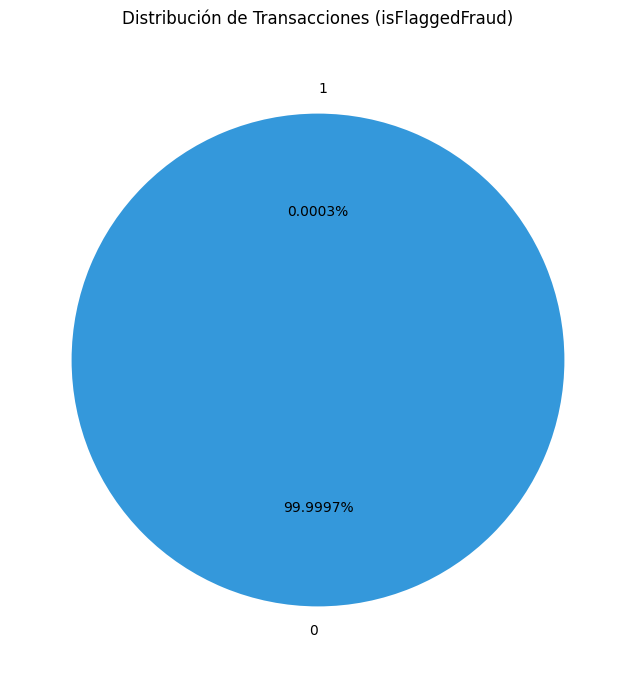

In [26]:
# Obtener los conteos
conteo_isflagged = data['isFlaggedFraud'].value_counts()

# Crear la gráfica de pastel
conteo_isflagged.plot(
    kind='pie', 
    figsize=(8, 8), 
    colors=['#3498db', '#e74c3c'], # Azul para normal, rojo para marcado
    autopct='%1.4f%%',             # Muestra el porcentaje con 4 decimales
    startangle=90                  # Gira el gráfico para mejor estética
)

plt.title('Distribución de Transacciones (isFlaggedFraud)', pad=20)
plt.ylabel('')  # Ocultamos el ylabel porque en gráficas de pastel genera ruido visual

# Mostrar el gráfico
plt.show()

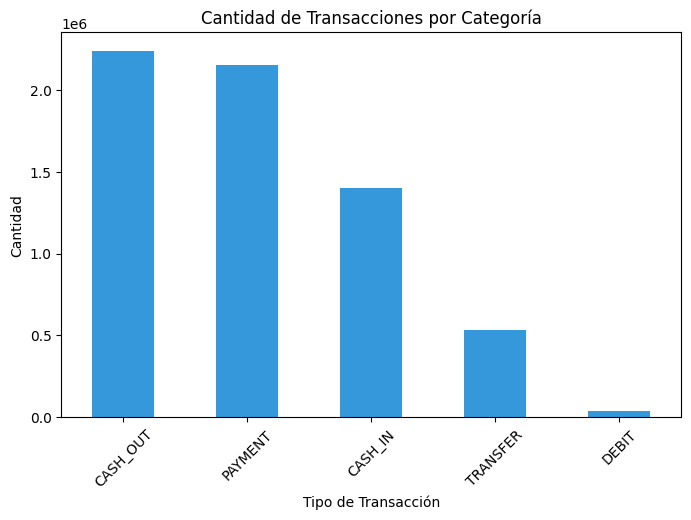

In [27]:
conteo_categorias = data['type'].value_counts()

conteo_categorias.plot(kind='bar', color='#3498db', figsize=(8, 5))

plt.title('Cantidad de Transacciones por Categoría')
plt.xlabel('Tipo de Transacción')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) 
plt.show()

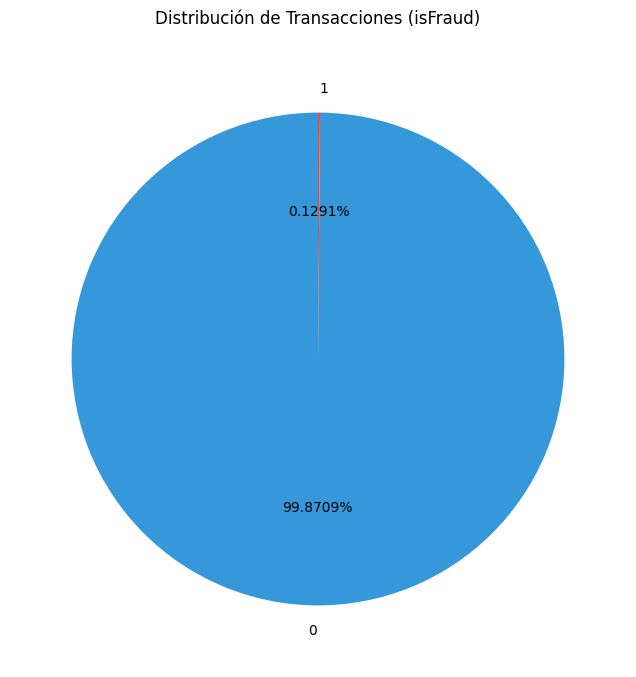

In [28]:
# Obtener los conteos
conteo_isfraud = data['isFraud'].value_counts()

# Crear la gráfica de pastel
conteo_isfraud.plot(
    kind='pie', 
    figsize=(8, 8), 
    colors=['#3498db', '#e74c3c'], # Azul para normal, rojo para marcado
    autopct='%1.4f%%',             # Muestra el porcentaje con 4 decimales
    startangle=90                  # Gira el gráfico para mejor estética
)

plt.title('Distribución de Transacciones (isFraud)', pad=20)
plt.ylabel('')  # Ocultamos el ylabel porque en gráficas de pastel genera ruido visual

# Mostrar el gráfico
plt.show()

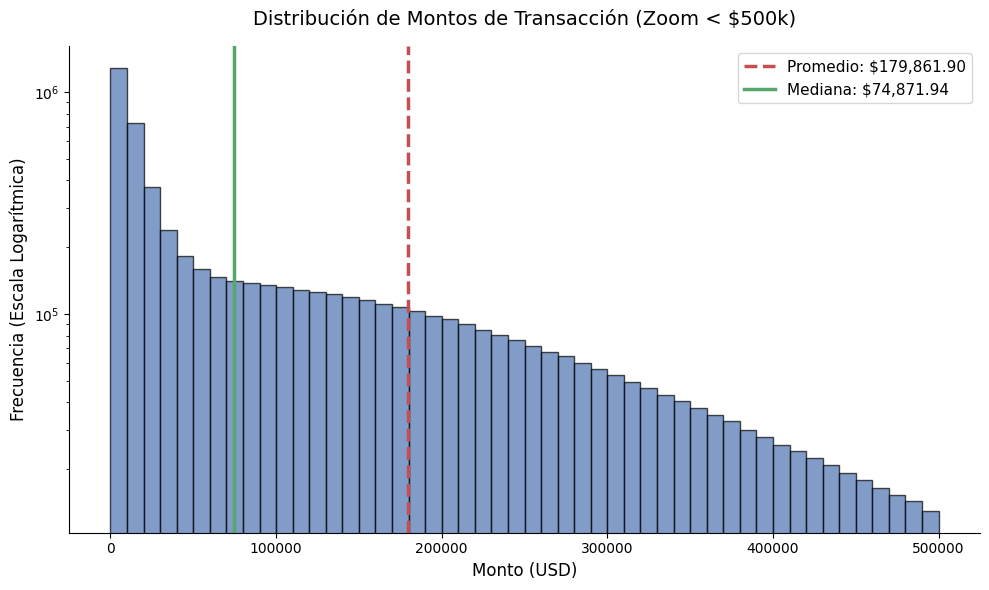

In [29]:
promedio = data['amount'].mean()
mediana = data['amount'].median()

plt.figure(figsize=(10, 6))
    

limite_visual = 500000 
plt.hist(data['amount'], bins=50, range=(0, limite_visual), 
         color='#4C72B0', edgecolor='black', alpha=0.7)

plt.axvline(promedio, color='#C44E52', linestyle='dashed', linewidth=2.5, 
            label=f'Promedio: ${promedio:,.2f}')
plt.axvline(mediana, color='#55A868', linestyle='solid', linewidth=2.5, 
            label=f'Mediana: ${mediana:,.2f}')


plt.yscale('log')


plt.title('Distribución de Montos de Transacción (Zoom < $500k)', fontsize=14, pad=15)
plt.xlabel('Monto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Escala Logarítmica)', fontsize=12)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Mostrar leyenda y ajustar diseño
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

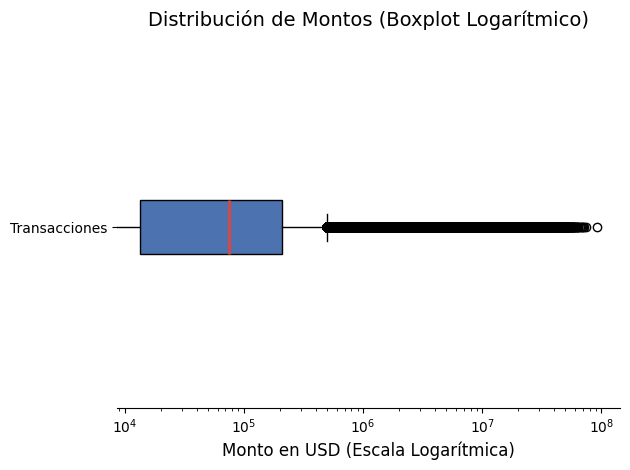

In [30]:

# Crear el boxplot en orientación horizontal (vert=False) para mejor lectura
plt.boxplot(data['amount'], 
            vert=False, 
            patch_artist=True,  # Permite colorear la caja
            boxprops=dict(facecolor='#4C72B0', color='black'),
            medianprops=dict(color='#C44E52', linewidth=2.5))

# TRUCO: Escala logarítmica en el eje X para manejar los millones
plt.xscale('log')

# Estilizar la gráfica
plt.title('Distribución de Montos (Boxplot Logarítmico)', fontsize=14, pad=15)
plt.xlabel('Monto en USD (Escala Logarítmica)', fontsize=12)
plt.yticks([1], ['Transacciones']) # Limpiamos el texto del eje Y

# Quitar bordes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
for columna in data.columns:
    
    # Calculamos la cantidad de ceros solo para la columna actual
    cantidad_ceros = (data[columna] == 0).sum()
    
    # Imprimimos el resultado de forma legible
    print(f"La columna '{columna}' tiene {cantidad_ceros} filas con valor 0.")

La columna 'step' tiene 0 filas con valor 0.
La columna 'type' tiene 0 filas con valor 0.
La columna 'amount' tiene 16 filas con valor 0.
La columna 'nameOrig' tiene 0 filas con valor 0.
La columna 'oldbalanceOrg' tiene 2102449 filas con valor 0.
La columna 'newbalanceOrig' tiene 3609566 filas con valor 0.
La columna 'nameDest' tiene 0 filas con valor 0.
La columna 'oldbalanceDest' tiene 2704388 filas con valor 0.
La columna 'newbalanceDest' tiene 2439433 filas con valor 0.
La columna 'isFraud' tiene 6354407 filas con valor 0.
La columna 'isFlaggedFraud' tiene 6362604 filas con valor 0.


In [32]:
data_0_amount = data[data['amount'] == 0]
print(data_0_amount)

         step      type  amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
2736447   212  CASH_OUT     0.0  C1510987794            0.0             0.0   
3247298   250  CASH_OUT     0.0   C521393327            0.0             0.0   
3760289   279  CASH_OUT     0.0   C539112012            0.0             0.0   
5563714   387  CASH_OUT     0.0  C1294472700            0.0             0.0   
5996408   425  CASH_OUT     0.0   C832555372            0.0             0.0   
5996410   425  CASH_OUT     0.0    C69493310            0.0             0.0   
6168500   554  CASH_OUT     0.0    C10965156            0.0             0.0   
6205440   586  CASH_OUT     0.0  C1303719003            0.0             0.0   
6266414   617  CASH_OUT     0.0  C1971175979            0.0             0.0   
6281483   646  CASH_OUT     0.0  C2060908932            0.0             0.0   
6281485   646  CASH_OUT     0.0  C1997645312            0.0             0.0   
6296015   671  CASH_OUT     0.0  C1960007029        

In [33]:
data_fraud = data[data['isFraud'] == 1]
print(data_fraud)

         step      type      amount     nameOrig  oldbalanceOrg  \
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
251         1  TRANSFER     2806.00  C1420196421        2806.00   
252         1  CASH_OUT     2806.00  C2101527076        2806.00   
680         1  TRANSFER    20128.00   C137533655       20128.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
2                   0.0   C553264065            0.00            0.00        1   
3                   0.0    C38997

In [34]:
# 1. Top 10 cuentas de origen que MÁS transacciones hicieron
top_10_origen_freq = data['nameOrig'].value_counts().head(10)

# 2. Top 10 cuentas de destino que MÁS transacciones recibieron
top_10_destino_freq = data['nameDest'].value_counts().head(10)

print("--- Top 10 Cuentas Origen (Frecuencia) ---")
print(top_10_origen_freq)

print("\n--- Top 10 Cuentas Destino (Frecuencia) ---")
print(top_10_destino_freq)

--- Top 10 Cuentas Origen (Frecuencia) ---
nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

--- Top 10 Cuentas Destino (Frecuencia) ---
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64


In [35]:
# 1. Top 10 cuentas de origen de donde más dinero salió
top_10_origen_vol = data.groupby('nameOrig')['amount'].sum().nlargest(10)

# 2. Top 10 cuentas de destino que más dinero recibieron
top_10_destino_vol = data.groupby('nameDest')['amount'].sum().nlargest(10)

print("--- Top 10 Cuentas Origen (Volumen de Dinero USD) ---")
print(top_10_origen_vol)

print("\n--- Top 10 Cuentas Destino (Volumen de Dinero USD) ---")
print(top_10_destino_vol)

--- Top 10 Cuentas Origen (Volumen de Dinero USD) ---
nameOrig
C1715283297    92445516.64
C2127282686    73823490.36
C2044643633    71172480.42
C1425667947    69886731.30
C1584456031    69337316.27
C811810230     67500761.29
C420748282     66761272.21
C1139847449    64234448.19
C300140823     63847992.58
C372535854     63294839.63
Name: amount, dtype: float64

--- Top 10 Cuentas Destino (Volumen de Dinero USD) ---
nameDest
C439737079     3.574408e+08
C707403537     2.993744e+08
C167875008     2.747364e+08
C20253152      2.701162e+08
C172409641     2.553102e+08
C268913927     2.534846e+08
C936857833     2.277800e+08
C65111466      2.274438e+08
C744189981     2.251739e+08
C1406193485    2.247790e+08
Name: amount, dtype: float64


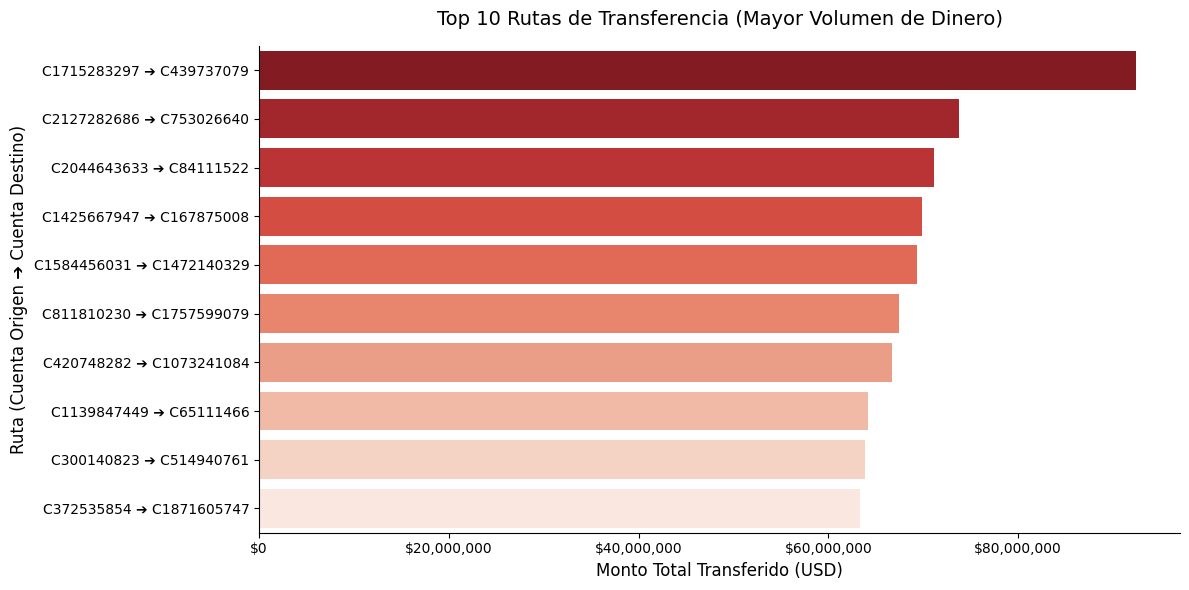

In [36]:
# 1. Crear una nueva columna que defina la "Ruta"
# Ejemplo: "C1234 ➔ C9876"
data['ruta_transferencia'] = data['nameOrig'].astype(str) + " ➔ " + data['nameDest'].astype(str)

# 2. Agrupar por ruta, sumar los montos y sacar el Top 10
top_rutas = data.groupby('ruta_transferencia')['amount'].sum().nlargest(10).reset_index()

# 3. Configurar el lienzo
plt.figure(figsize=(12, 6))

# 4. Crear la gráfica de barras horizontales
# Usamos seaborn porque maneja automáticamente los colores y el mapeo categórico
sns.barplot(
    x='amount', 
    y='ruta_transferencia', 
    data=top_rutas, 
    palette='Reds_r' # Una paleta roja descendente (alerta/riesgo)
)

# 5. Estilizar la gráfica para el reporte de auditoría
plt.title('Top 10 Rutas de Transferencia (Mayor Volumen de Dinero)', fontsize=14, pad=15)
plt.xlabel('Monto Total Transferido (USD)', fontsize=12)
plt.ylabel('Ruta (Cuenta Origen ➔ Cuenta Destino)', fontsize=12)

# Darle formato de moneda al eje X
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# Quitar bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

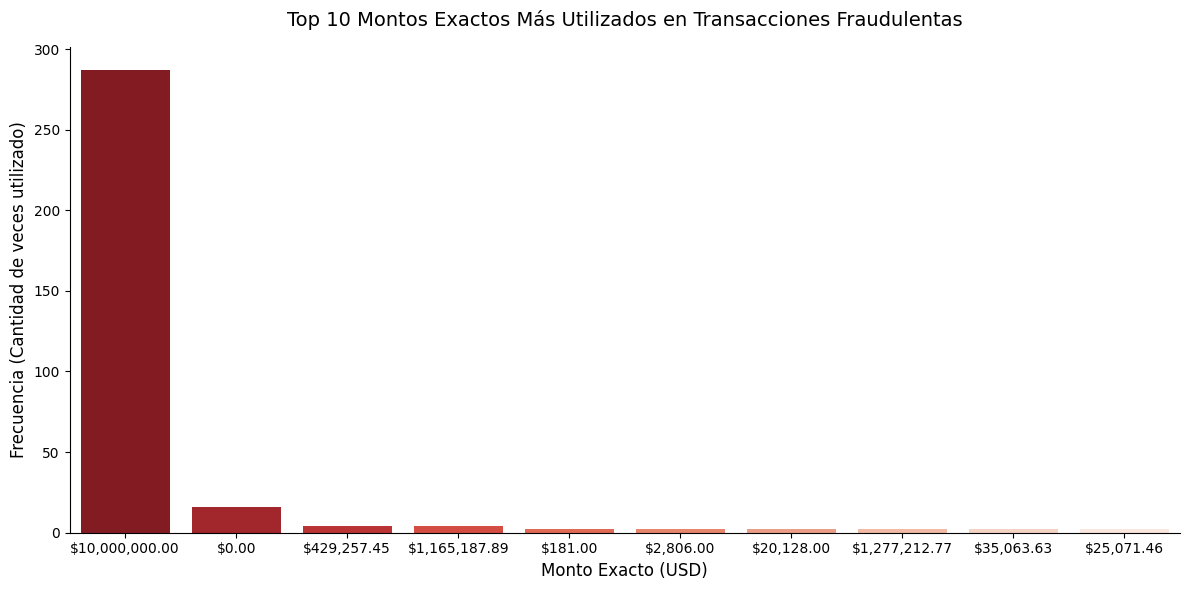

In [37]:
df_solo_fraudes = data[data['isFraud'] == 1]

# 2. Contar cuáles son los montos EXACTOS que más se repiten y sacar el Top 10
montos_comunes = df_solo_fraudes['amount'].value_counts().head(10).reset_index()
montos_comunes.columns = ['monto_exacto', 'cantidad_de_fraudes']

# 3. Configurar el lienzo
plt.figure(figsize=(12, 6))

# 4. Crear la gráfica de barras
# Convertimos los montos a texto (string) en el eje X para que Matplotlib 
# los trate como categorías discretas y no intente ordenarlos matemáticamente.
sns.barplot(
    x=montos_comunes['monto_exacto'].astype(str), 
    y=montos_comunes['cantidad_de_fraudes'], 
    palette='Reds_r' # Rojo intenso para resaltar el riesgo
)

# 5. Estilizar la gráfica
plt.title('Top 10 Montos Exactos Más Utilizados en Transacciones Fraudulentas', fontsize=14, pad=15)
plt.xlabel('Monto Exacto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de veces utilizado)', fontsize=12)

# Añadir el símbolo de dólar a las etiquetas del eje X
ax = plt.gca()
ax.set_xticklabels([f"${float(x.get_text()):,.2f}" for x in ax.get_xticklabels()])

# Quitar bordes para el estilo de auditoría
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

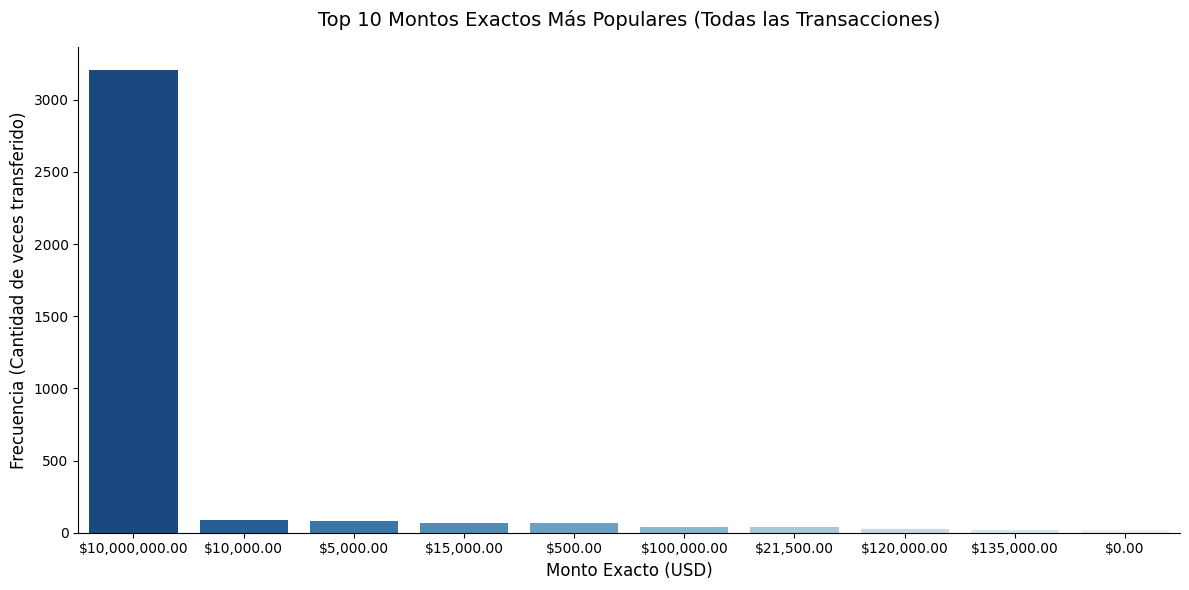

In [38]:

montos_comunes = data['amount'].value_counts().head(10).reset_index()

# Corregimos el nombre de la columna para que tenga sentido (ya no son fraudes)
montos_comunes.columns = ['monto_exacto', 'frecuencia']

# 2. Configurar el lienzo
plt.figure(figsize=(12, 6))

# 3. Crear la gráfica de barras
# Convertimos los montos a texto (string) en el eje X
sns.barplot(
    x=montos_comunes['monto_exacto'].astype(str), 
    y=montos_comunes['frecuencia'], 
    palette='Blues_r' # Azul para comportamiento general (reservamos el rojo para fraudes)
)

# 4. Estilizar la gráfica
plt.title('Top 10 Montos Exactos Más Populares (Todas las Transacciones)', fontsize=14, pad=15)
plt.xlabel('Monto Exacto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de veces transferido)', fontsize=12)

# Añadir el símbolo de dólar a las etiquetas del eje X
ax = plt.gca()
ax.set_xticklabels([f"${float(x.get_text()):,.2f}" for x in ax.get_xticklabels()])

# Quitar bordes para el estilo de auditoría
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

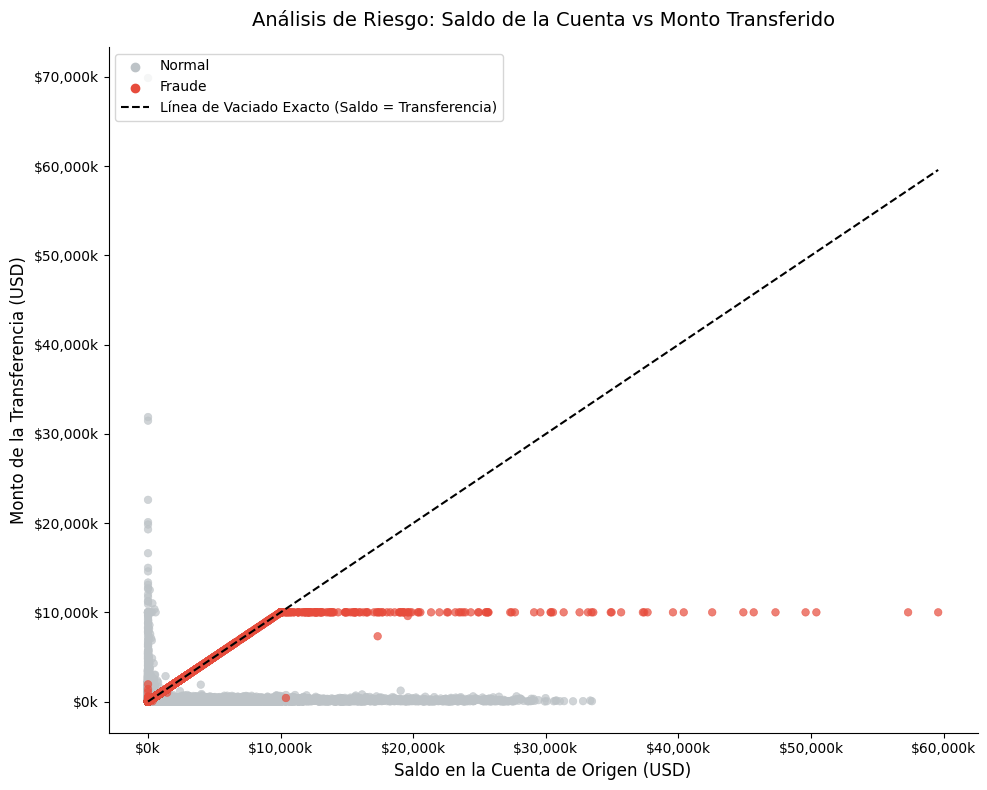

In [41]:
# 1. Preparación de los datos
df_fraudes = data[data['isFraud'] == 1]
df_normales = data[data['isFraud'] == 0].sample(n=50000, random_state=42)

# Unimos ambos para graficar
df_plot = pd.concat([df_normales, df_fraudes])

# CORRECCIÓN: Creamos una nueva columna temporal con etiquetas de texto 
# para que la leyenda de la gráfica y la paleta de colores funcionen perfectamente.
df_plot['Tipo de Transacción'] = df_plot['isFraud'].map({0: 'Normal', 1: 'Fraude'})

# 2. Configurar el lienzo
plt.figure(figsize=(10, 8))

# 3. Crear el gráfico de dispersión
sns.scatterplot(
    data=df_plot,
    x='oldbalanceOrg',  
    y='amount',         
    hue='Tipo de Transacción', # Usamos nuestra nueva columna de texto
    palette={'Normal': '#BDC3C7', 'Fraude': '#E74C3C'}, # Ahora sí coinciden las llaves
    alpha=0.7,          
    s=30,               
    edgecolor=None
)

# 4. Línea de referencia del "Vaciado de Cuenta"
max_val = min(df_plot['oldbalanceOrg'].max(), df_plot['amount'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=1.5, 
         label='Línea de Vaciado Exacto (Saldo = Transferencia)')

# 5. Estilizar la gráfica
plt.title('Análisis de Riesgo: Saldo de la Cuenta vs Monto Transferido', fontsize=14, pad=15)
plt.xlabel('Saldo en la Cuenta de Origen (USD)', fontsize=12)
plt.ylabel('Monto de la Transferencia (USD)', fontsize=12)

# Formato de moneda en los ejes
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1e3:,.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1e3:,.0f}k'))

# Limpiar bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajustamos la leyenda para que se vea limpia
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()